<h2>LEVEL 3 - TASK 1: PREDICTIVE MODELING</h2>

<h3>EXPLORE DATA</h3>

In [1]:
import pandas as pd

# Load datasets
train = pd.read_csv("churn-bigml-80.csv")
test = pd.read_csv("churn-bigml-20.csv")

# Inspect data
print(train.shape)
print(train.head())
print(train.info())
print(train.isnull().sum())

(2666, 20)
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1          

Standardize target variable

In [2]:
# Convert Churn to numeric
train['Churn'] = train['Churn'].map({False:0, True:1, 'FALSE':0, 'TRUE':1})
test['Churn'] = test['Churn'].map({False:0, True:1, 'FALSE':0, 'TRUE':1})

Encode Yes/No columns

In [3]:
binary_cols = ['International plan', 'Voice mail plan']

for col in binary_cols:
    train[col] = train[col].map({'No':0, 'Yes':1})
    test[col] = test[col].map({'No':0, 'Yes':1})

One-hot encode categorical variables

In [4]:
categorical_cols = ['State', 'Area code']

train = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

Scale numeric features

In [5]:
from sklearn.preprocessing import StandardScaler

# Select numeric features to scale
numeric_cols = [
    'Account length', 'Number vmail messages',
    'Total day minutes', 'Total day calls', 'Total day charge',
    'Total eve minutes', 'Total eve calls', 'Total eve charge',
    'Total night minutes', 'Total night calls', 'Total night charge',
    'Total intl minutes', 'Total intl calls', 'Total intl charge',
    'Customer service calls'
]

scaler = StandardScaler()
train[numeric_cols] = scaler.fit_transform(train[numeric_cols])
test[numeric_cols] = scaler.transform(test[numeric_cols])

Split features and target

In [6]:
X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

Train Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

Evaluate the Model

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision
prec = precision_score(y_test, y_pred)

# Recall
rec = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance:")
print("Accuracy:", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall:", round(rec, 3))
print("F1 Score:", round(f1, 3))

Logistic Regression Performance:
Accuracy: 0.855
Precision: 0.477
Recall: 0.221
F1 Score: 0.302


Confusion Matrix

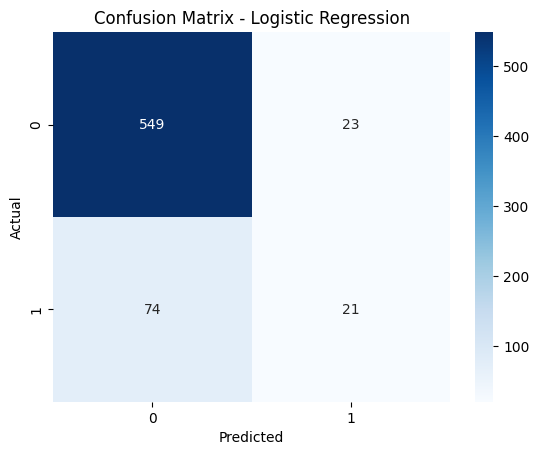

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Decision Tree Classifier

In [11]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

Evaluating Decision Tree

In [12]:
# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)

# Precision
prec_dt = precision_score(y_test, y_pred_dt)

# Recall
rec_dt = recall_score(y_test, y_pred_dt)

# F1 Score
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print("Accuracy:", round(acc_dt, 3))
print("Precision:", round(prec_dt, 3))
print("Recall:", round(rec_dt, 3))
print("F1 Score:", round(f1_dt, 3))

Decision Tree Performance:
Accuracy: 0.918
Precision: 0.692
Recall: 0.758
F1 Score: 0.724


Confusion Matrix for Decision Tree

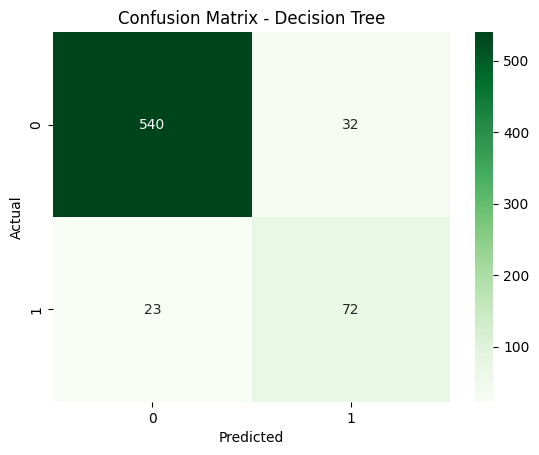

In [13]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

Evaluating Random Forest

In [15]:
# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

# Precision
prec_rf = precision_score(y_test, y_pred_rf)

# Recall
rec_rf = recall_score(y_test, y_pred_rf)

# F1 Score
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("Accuracy:", round(acc_rf, 3))
print("Precision:", round(prec_rf, 3))
print("Recall:", round(rec_rf, 3))
print("F1 Score:", round(f1_rf, 3))

Random Forest Performance:
Accuracy: 0.942
Precision: 0.952
Recall: 0.621
F1 Score: 0.752


Confusion Matrix for Random Forest

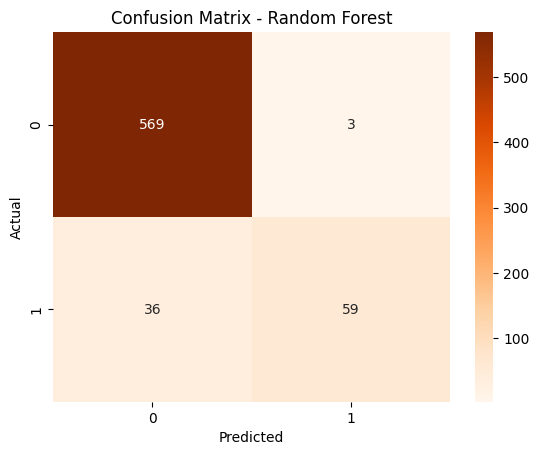

In [16]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Hyperparameter Tuning with Grid Search

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 5, 10, 15],      # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],     # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2']     # Number of features to consider at each split
}

# Create a Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring='f1',         # Optimize based on F1-score
    n_jobs=-1             # Use all cores
)

# Fit Grid Search on the training data
grid_search.fit(X_train, y_train)

# Best parameters and best F1-score
print("Best parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 3))

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.728


Evaluate the Best Model on Test Data

In [18]:
# Get the best model
best_rf = grid_search.best_estimator_

# Predict on test set
y_pred_best = best_rf.predict(X_test)

# Evaluate
acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print("Random Forest (Tuned) Performance on Test Set:")
print("Accuracy:", round(acc_best, 3))
print("Precision:", round(prec_best, 3))
print("Recall:", round(rec_best, 3))
print("F1 Score:", round(f1_best, 3))

Random Forest (Tuned) Performance on Test Set:
Accuracy: 0.946
Precision: 0.984
Recall: 0.632
F1 Score: 0.769


View Predictions

In [19]:
# Predict churn on the test set
y_pred_best = best_rf.predict(X_test)

# Show first 10 predictions
print("Predicted Churn (0 = No, 1 = Yes):")
print(y_pred_best[:10])

# Compare with actual values
print("\nActual Churn values:")
print(y_test.values[:10])

Predicted Churn (0 = No, 1 = Yes):
[0 1 1 0 0 0 0 0 0 0]

Actual Churn values:
[0 1 1 0 0 0 0 1 0 0]


In [20]:
# Copy test data
test_results = X_test.copy()

# Add actual and predicted churn
test_results['Actual_Churn'] = y_test.values
test_results['Predicted_Churn'] = y_pred_best

# View first 10 rows
print(test_results.head(10))

   Account length  International plan  Voice mail plan  Number vmail messages  \
0        0.414080                   0                0              -0.589414   
1       -0.900493                   0                0              -0.589414   
2        1.526412                   0                0              -0.589414   
3        0.262399                   0                0              -0.589414   
4       -1.304977                   0                0              -0.589414   
5       -1.633621                   0                1               1.614893   
6       -0.900493                   0                0              -0.589414   
7        0.464641                   0                0              -0.589414   
8       -2.290908                   0                0              -0.589414   
9       -0.824652                   0                0              -0.589414   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0           0.092590        -0